# Deep Equilibrium Models and SILVA

The DEQ baseline in this notebook solves

$$
z^\star=\tanh(W_z z^\star+W_x x+b).
$$

SILVA keeps the same fixed-point idea but splits the transition into named
branches:

$$
z^\star
=\sigma\{S_\theta(x)+H_\theta(z^\star)+L_\theta(z^\star)+G_\theta(z^\star)\}.
$$

The names are operational:

- $S_\theta$: stimulus from data.
- $H_\theta$: optional learned self-interaction inside the transition.
- $L_\theta$: local interaction, for example graph messages or dynamic kNN.
- $G_\theta$: global context, for example mean field or bounded attention.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## DEQ MLP Baseline

This mirrors the compact DEQ experiment: solve one equilibrium state and train a
linear readout on top.

In [3]:
from silva_networks import silva_fixed_point_classifier

x = torch.randn(40, 6, device=device)
y = (x[:, :3].sum(dim=1) > x[:, 3:].sum(dim=1)).long()
deq_model = silva_fixed_point_classifier(
    in_features=6,
    state_dim=16,
    num_classes=2,
    config=SolverConfig(solver="anderson", max_iter=8, alpha=0.6, history=4),
).to(device)

out = deq_model(x, return_result=True)
loss = torch.nn.functional.cross_entropy(out.output, y)
loss.backward()
out.output.shape, out.solver_result.solver, out.solver_result.residual

(torch.Size([40, 2]), 'anderson', 0.03303724527359009)

## SILVA Graph Variant

Now convert the same rows into graph entities. A k-nearest-neighbor graph
defines local messages, while a mean-field or attention term supplies global
context.

In [4]:
from silva_networks import SILVAGraphNetwork, make_knn_edge_index

edge_index = make_knn_edge_index(x.detach(), k=4, metric="cosine", undirected=True, device=device)
silva = SILVAGraphNetwork(
    in_dim=6,
    hidden_dims=[16, 16],
    out_dim=2,
    task="node",
    local=["graph", "gat"],
    global_term=["mean", "topk"],
    self_term=["none", "linear"],
    local_kwargs=[{}, {"heads": 4, "add_self_loops": True}],
    global_kwargs=[{}, {"k": 6}],
    config=[
        SolverConfig(solver="picard", max_iter=6, alpha=0.55),
        SolverConfig(solver="anderson", max_iter=6, alpha=0.45, history=3),
    ],
).to(device)

result = silva(x, edge_index=edge_index, return_results=True)
silva_loss = torch.nn.functional.cross_entropy(result.output, y)
silva_loss.backward()
result.output.shape, result.state.shape, [r.solver for r in result.solver_results]

(torch.Size([40, 2]), torch.Size([40, 16]), ['picard', 'anderson'])

## Residual Diagnostics

Both models are controlled by `SolverConfig`. The solver choice, damping,
history, tolerance, and iteration budget can be changed per layer.

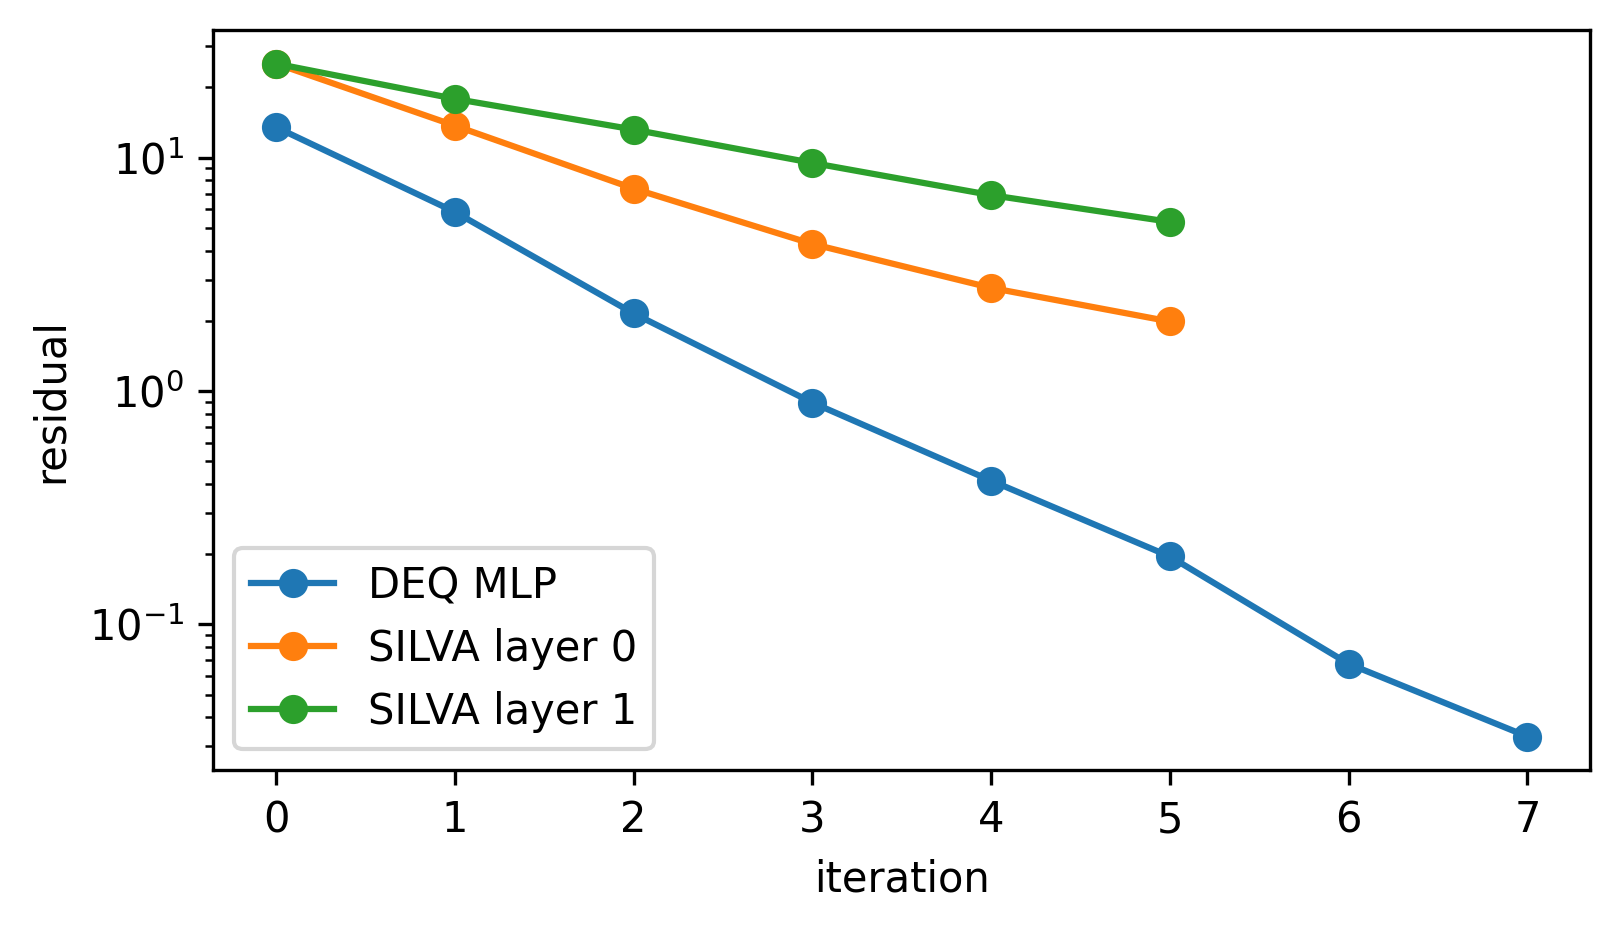

In [5]:
plt.figure(figsize=(5.5, 3.2))
plt.plot(out.solver_result.residuals, marker="o", label="DEQ MLP")
for index, solver_result in enumerate(result.solver_results):
    plt.plot(solver_result.residuals, marker="o", label=f"SILVA layer {index}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("residual")
plt.legend()
plt.tight_layout()

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770099
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.